**TRABAJO FINAL DE REDES NEURONALES**

ESTUDIANTE: **Luis Emilio Moreno Sánchez**

**SITUACION:** FoodSnaps tiene 800+ restaurantes activos con 12 platos nuevos por semana cada uno.

**RETO:** Desarrollar un modelo que pueda clasificar con éxito cada plato nuevo que es subido por el restaurante.

**PRODUCTO FINAL:** El Modelo desarrollado genera un acierto del 76% entre la elección de 101 clases diferentes de comida.

Este notebook contiene la investigación y el entrenamiento del modelo adecuado para el reto. El segundo notebook contiene el despliegue del modelo en HuggingFace.

In [ ]:
# LINK A HUGGINGFACE

https://huggingface.co/spaces/luisemilio00/Food_Class

## 1. Importar Librerias

In [ ]:
# Imports
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import load_model

import collections

import json

import time

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

print("=" * 60)
print("CONFIGURACIÓN")
print("=" * 60)
print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")
print("=" * 60)

CONFIGURACIÓN
TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Definicion de Hiperparametros

In [ ]:
# Configuración
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS_FE = 10  # Only classifier
EPOCHS_FT = 5   # Descongelar Capas de Convolución conv
LR_FE = 0.0017
LR_FT = 0.0001
NUM_CLASSES = 'desconocido por el momento'

print(f"✓ IMG_SIZE={IMG_SIZE}, BATCH={BATCH_SIZE}, CLASSES={NUM_CLASSES}")

✓ IMG_SIZE=224, BATCH=32, CLASSES=desconocido por el momento


## 3. Conociendo el DATASET


EJEMPLO 1: Carga básica y exploración del dataset food101


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.52EBRU_2.0.0/food101-train.tfrecord*...:   0%|         …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.52EBRU_2.0.0/food101-validation.tfrecord*...:   0%|    …

Dataset food101 downloaded and prepared to /root/tensorflow_datasets/food101/2.0.0. Subsequent calls will reuse this data.
Dataset cargado: food101 version 2.0.0
Número de clases: 101
Nombres de las clases: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito', 'bruschetta', 'caesar_salad', 'cannoli', 'caprese_salad', 'carrot_cake', 'ceviche', 'cheesecake', 'cheese_plate', 'chicken_curry', 'chicken_quesadilla', 'chicken_wings', 'chocolate_cake', 'chocolate_mousse', 'churros', 'clam_chowder', 'club_sandwich', 'crab_cakes', 'creme_brulee', 'croque_madame', 'cup_cakes', 'deviled_eggs', 'donuts', 'dumplings', 'edamame', 'eggs_benedict', 'escargots', 'falafel', 'filet_mignon', 'fish_and_chips', 'foie_gras', 'french_fries', 'french_onion_soup', 'french_toast', 'fried_calamari', 'fried_rice', 'frozen_yogurt', 'garlic_bread', 'gnocchi', 'greek_salad', 'grilled_cheese_sandwich', 'grilled_salmon', '

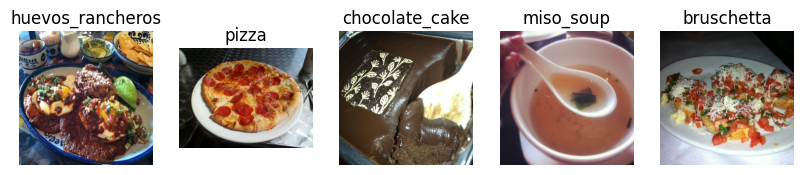

In [ ]:
# Cargar el dataset y explorar su información
print("\n" + "=" * 60)
print("EJEMPLO 1: Carga básica y exploración del dataset food101")
print("=" * 60)

# Cargar el dataset food101. 'as_supervised=True' para obtener (imagen, etiqueta) y 'with_info=True' para obtener metadatos.
# Dividimos en 'train' y 'validation' que son los splits disponibles en food101.
(ds_train_info, ds_validation_info), ds_info = tfds.load(
    'food101',
    split=['train', 'validation'],
    as_supervised=True,
    with_info=True
)

print(f"Dataset cargado: {ds_info.name} version {ds_info.version}")
print(f"Número de clases: {ds_info.features['label'].num_classes}")
print(f"Nombres de las clases: {ds_info.features['label'].names}")
print(f"Tamaño del split de entrenamiento: {ds_info.splits['train'].num_examples}")
print(f"Tamaño del split de validación: {ds_info.splits['validation'].num_examples}")

# Mostrar algunas imágenes de ejemplo (opcional)
print("\nMostrando 5 imágenes de ejemplo del dataset de entrenamiento:")
plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(ds_train_info.take(5)):
    ax = plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.title(ds_info.features['label'].names[label.numpy()])
    plt.axis("off")
plt.show()

In [ ]:
NUM_CLASSES = ds_info.features['label'].num_classes

print(f"✓ IMG_SIZE={IMG_SIZE}, BATCH={BATCH_SIZE}, CLASSES={NUM_CLASSES}")

✓ IMG_SIZE=224, BATCH=32, CLASSES=101



VISUALIZACIÓN DE CLASES EN EL DATASET DE ENTRENAMIENTO


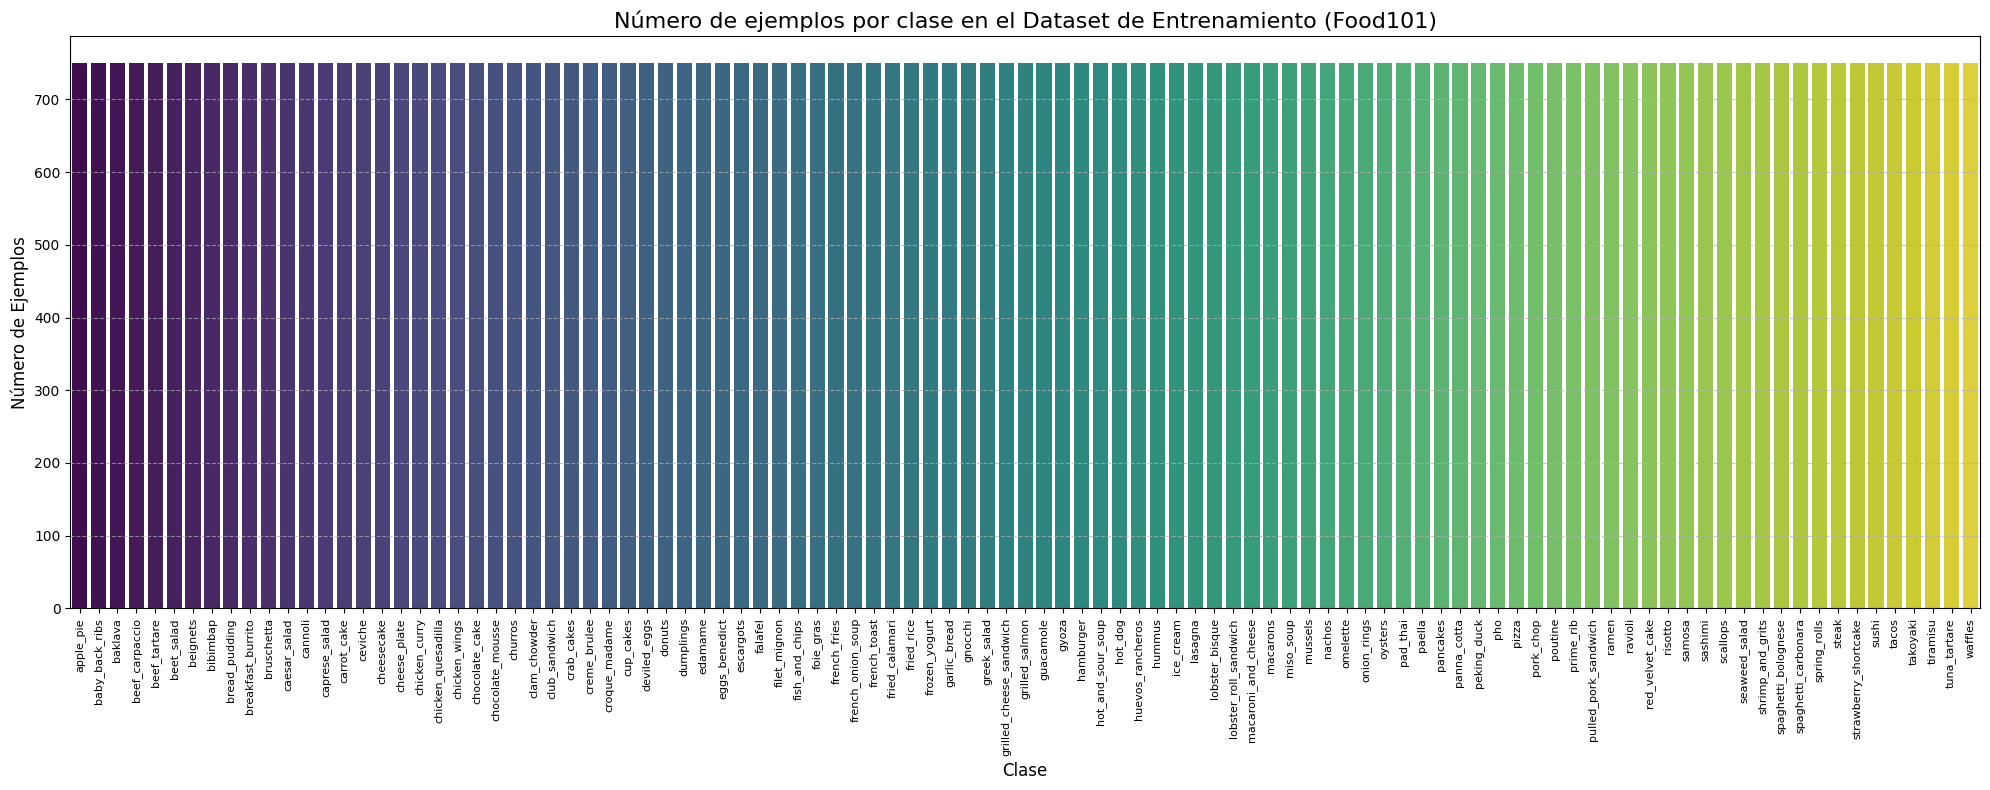

Número total de clases en el entrenamiento: 101
Recuento de las primeras 10 clases en entrenamiento: [(np.int64(56), 750), (np.int64(76), 750), (np.int64(21), 750), (np.int64(64), 750), (np.int64(10), 750), (np.int64(70), 750), (np.int64(90), 750), (np.int64(100), 750), (np.int64(53), 750), (np.int64(73), 750)]


In [ ]:
# 1. Visualización de clases en el dataset de entrenamiento

print("\n" + "=" * 60)
print("VISUALIZACIÓN DE CLASES EN EL DATASET DE ENTRENAMIENTO")
print("=" * 60)

# Obtener nombres de las clases
class_names = ds_info.features['label'].names

# Recopilar etiquetas del dataset de entrenamiento
train_labels = []
for _, label in ds_train_info:
    train_labels.append(label.numpy())

# Contar ocurrencias de cada clase
train_class_counts = collections.Counter(train_labels)

# Preparar datos para la visualización
train_class_ids = sorted(train_class_counts.keys())
train_counts = [train_class_counts[class_id] for class_id in train_class_ids]
train_class_names_sorted = [class_names[class_id] for class_id in train_class_ids]

# Crear el gráfico de barras
plt.figure(figsize=(20, 8))
sns.barplot(x=train_class_names_sorted, y=train_counts, palette='viridis')
plt.title('Número de ejemplos por clase en el Dataset de Entrenamiento (Food101)', fontsize=16)
plt.xlabel('Clase', fontsize=12)
plt.ylabel('Número de Ejemplos', fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Número total de clases en el entrenamiento: {len(train_class_ids)}")
print(f"Recuento de las primeras 10 clases en entrenamiento: {train_class_counts.most_common(10)}")


VISUALIZACIÓN DE CLASES EN EL DATASET DE VALIDACIÓN


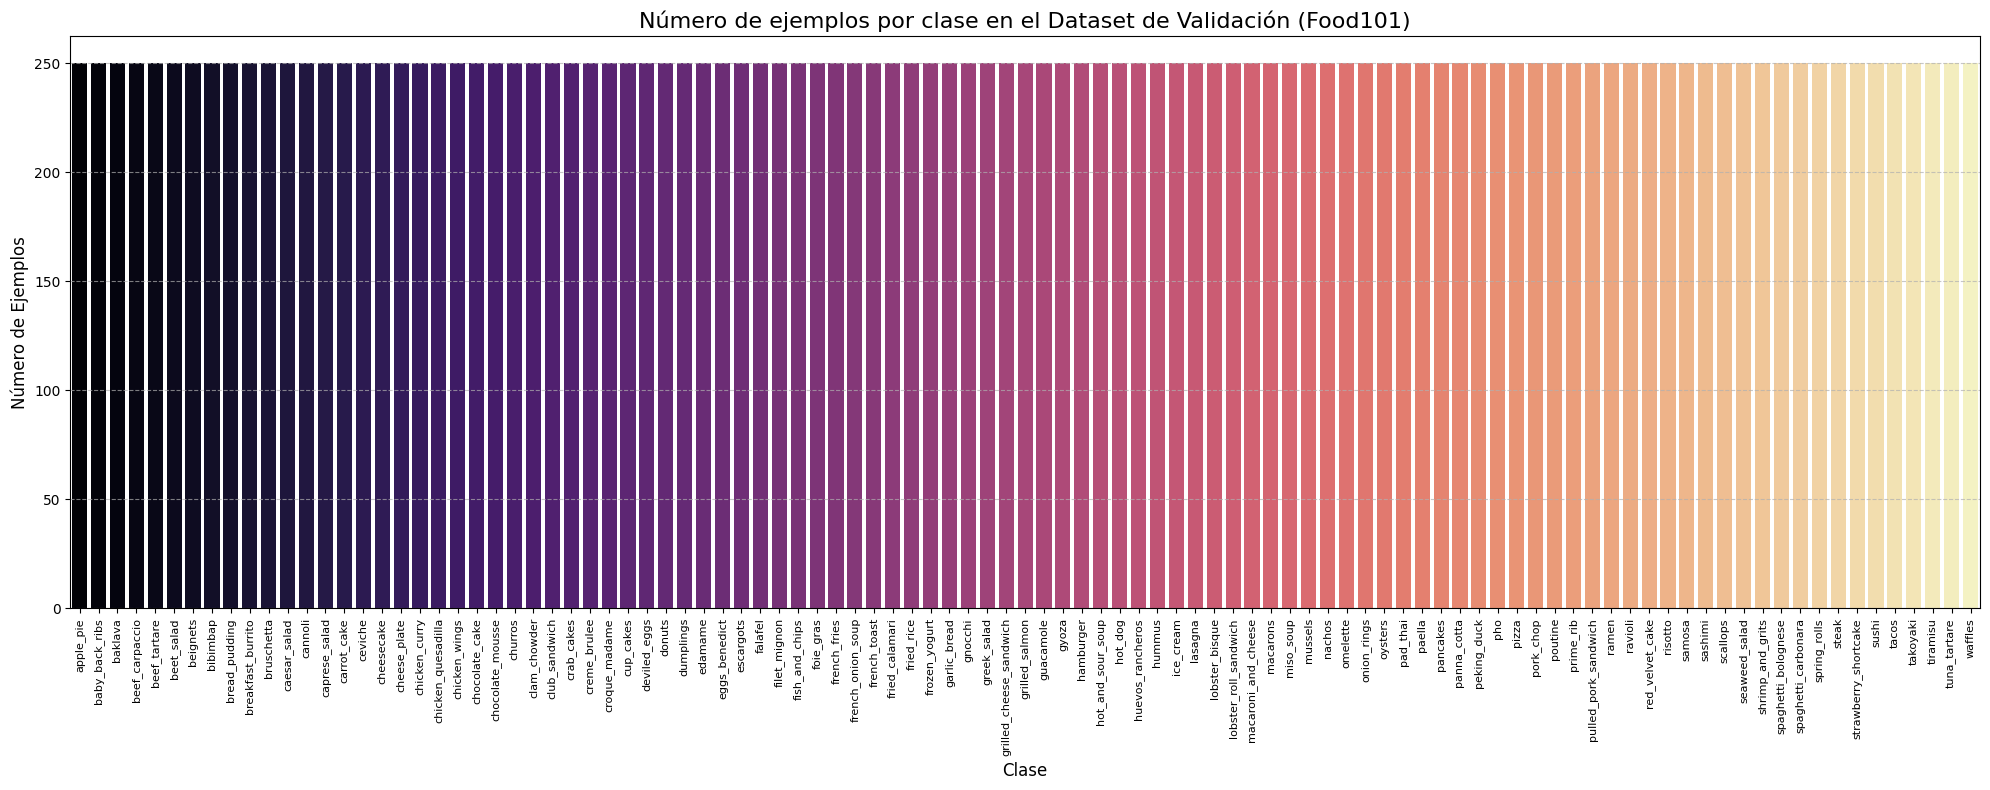

Número total de clases en la validación: 101
Recuento de las primeras 10 clases en validación: [(np.int64(29), 250), (np.int64(81), 250), (np.int64(91), 250), (np.int64(53), 250), (np.int64(97), 250), (np.int64(10), 250), (np.int64(31), 250), (np.int64(3), 250), (np.int64(100), 250), (np.int64(4), 250)]


In [ ]:
#Visualización de clases en el dataset de validación

print("\n" + "=" * 60)
print("VISUALIZACIÓN DE CLASES EN EL DATASET DE VALIDACIÓN")
print("=" * 60)

# Recopilar etiquetas del dataset de validación
val_labels = []
for _, label in ds_validation_info:
    val_labels.append(label.numpy())

# Contar ocurrencias de cada clase
val_class_counts = collections.Counter(val_labels)

# Preparar datos para la visualización
val_class_ids = sorted(val_class_counts.keys())
val_counts = [val_class_counts[class_id] for class_id in val_class_ids]
val_class_names_sorted = [class_names[class_id] for class_id in val_class_ids]

# Crear el gráfico de barras
plt.figure(figsize=(20, 8))
sns.barplot(x=val_class_names_sorted, y=val_counts, palette='magma')
plt.title('Número de ejemplos por clase en el Dataset de Validación (Food101)', fontsize=16)
plt.xlabel('Clase', fontsize=12)
plt.ylabel('Número de Ejemplos', fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Número total de clases en la validación: {len(val_class_ids)}")
print(f"Recuento de las primeras 10 clases en validación: {val_class_counts.most_common(10)}")

## 4. Preprocesamiento de Datos

In [ ]:
# Función de preprocesamiento para redimensionar y normalizar las imágenes
def preprocess_image(image, label):
    # Redimensionar la imagen a IMG_SIZE x IMG_SIZE
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    # modo Caffe (RGB→BGR + mean específico)
    image = resnet_preprocess(image)
    return image, label

# Aplicar la función de preprocesamiento a los datasets de entrenamiento y validación
ds_train_processed = ds_train_info.map(preprocess_image)
ds_validation_processed = ds_validation_info.map(preprocess_image)

print("Preprocesamiento de redimensionamiento y normalización aplicado a los datasets.")


Preprocesamiento de redimensionamiento y normalización aplicado a los datasets.



VERIFICACIÓN DE PREPROCESAMIENTO DE IMAGEN
Forma de la imagen preprocesada: (224, 224, 3)
Tipo de datos de la imagen preprocesada: <dtype: 'float32'>
Valor mínimo de píxel: -123.6800
Valor máximo de píxel: 151.0610


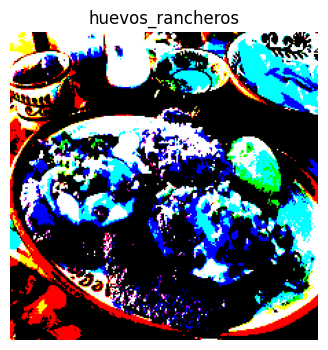


Como se puede observar, los valores de los píxeles están ahora en el rango de 0.0 a 1.0, y la imagen está redimensionada.


In [ ]:
# Verificar el rango de píxeles de una imagen de ejemplo después del preprocesamiento
print("\n" + "=" * 60)
print("VERIFICACIÓN DE PREPROCESAMIENTO DE IMAGEN")
print("=" * 60)

for image, label in ds_train_processed.take(1):
    print(f"Forma de la imagen preprocesada: {image.shape}")
    print(f"Tipo de datos de la imagen preprocesada: {image.dtype}")
    print(f"Valor mínimo de píxel: {tf.reduce_min(image).numpy():.4f}")
    print(f"Valor máximo de píxel: {tf.reduce_max(image).numpy():.4f}")

    # Mostrar la imagen preprocesada (opcional, para visualización)
    plt.figure(figsize=(4, 4))
    plt.imshow(image.numpy())
    plt.title(class_names[label.numpy()])
    plt.axis("off")
    plt.show()

print("\nComo se puede observar, los valores de los píxeles están ahora en el rango de 0.0 a 1.0, y la imagen está redimensionada.")

**Aumentación de Datos (Data Augmentation)**
La aumentación de datos es crucial cuando se tienen datasets de entrenamiento limitados, como en el caso de Food101 donde hay 750 imágenes por clase. Al generar nuevas variaciones de las imágenes existentes, aumentamos la diversidad del dataset y ayudamos al modelo a generalizar mejor, reduciendo el sobreajuste. Vamos a dejar la funcion de Aumento de Datos por ahora, y vamos a continuar sin aumento de datos.

In [ ]:
#Definir la capa de aumentación de datos

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"), # Voltea las imágenes horizontal al azar
        layers.RandomRotation(0.2),                   # Rota las imágenes hasta 20 grados al azar (en radianes)
        layers.RandomZoom(0.2),                      # Aplica un zoom aleatorio a las imágenes (hasta 20%)
        layers.RandomTranslation(height_factor=0.1, width_factor=0.1) # Traslada las imágenes horizontal y verticalmente hasta un 10%
    ],
    name="data_augmentation",
)

print("Capa de aumentación de datos definida con éxito.")

Capa de aumentación de datos definida con éxito.


... sin aumento de datos

In [ ]:
ds_train_optimized = ds_train_processed.shuffle(buffer_size=1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
ds_validation_optimized = ds_validation_processed.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
# Optimización del rendimiento del dataset con cache y prefetch
# Esto es importante para asegurar que los datos estén listos para el modelo sin cuellos de botella.

# Aplicar cache, shuffle, batch y prefetch al dataset de entrenamiento aumentado
#ds_train_optimized = ds_train_processed.cache().shuffle(buffer_size=1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Aplicar cache, batch y prefetch al dataset de validación preprocesado (sin aumentación)
#ds_validation_optimized = ds_validation_processed.cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Datasets optimizados para el entrenamiento (con aumentación) y la validación con tamaño de batch de {BATCH_SIZE}.")

Datasets optimizados para el entrenamiento (con aumentación) y la validación con tamaño de batch de 32.



VERIFICACIÓN DEL DATASET DE ENTRENAMIENTO AUMENTADO Y EN BATCHES


Forma del batch de imágenes: (32, 224, 224, 3)
Forma del batch de etiquetas: (32,)
Valor mínimo de píxel en el batch: -123.6800
Valor máximo de píxel en el batch: 151.0610


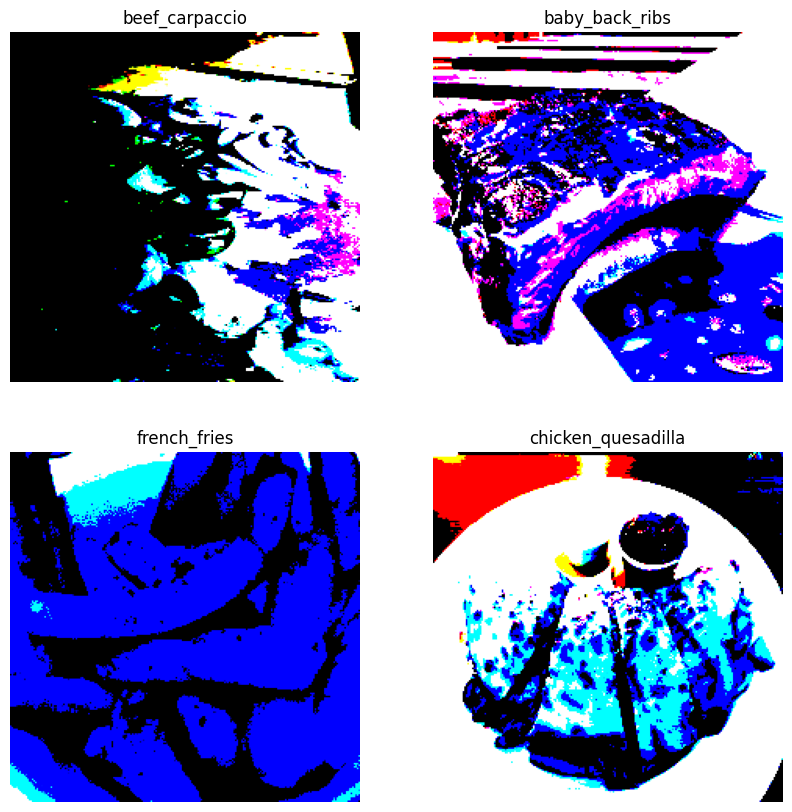

Puedes observar que las imágenes del batch muestran variaciones debido a la aumentación de datos.


In [ ]:
# Verificar el dataset de entrenamiento con aumentación y batching
print("\n" + "=" * 60)
print("VERIFICACIÓN DEL DATASET DE ENTRENAMIENTO AUMENTADO Y EN BATCHES")
print("=" * 60)

# Tomar un batch de imágenes y etiquetas del dataset de entrenamiento optimizado
for images, labels in ds_train_optimized.take(1):
    print(f"Forma del batch de imágenes: {images.shape}") # Debería ser (BATCH_SIZE, IMG_SIZE, IMG_SIZE, 3)
    print(f"Forma del batch de etiquetas: {labels.shape}") # Debería ser (BATCH_SIZE,)
    print(f"Valor mínimo de píxel en el batch: {tf.reduce_min(images).numpy():.4f}")
    print(f"Valor máximo de píxel en el batch: {tf.reduce_max(images).numpy():.4f}")

    # Mostrar algunas imágenes del batch para ver la aumentación
    plt.figure(figsize=(10, 10))
    for i in range(min(4, BATCH_SIZE)): # Mostrar hasta 4 imágenes del batch
        ax = plt.subplot(2, 2, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")
    plt.show()
    break

print("Puedes observar que las imágenes del batch muestran variaciones debido a la aumentación de datos.")

## 5. BUSCANDO EL MODELO DE CABEZA PERFECTO

... CARGANDO EL MODELO RESNET50 ...

In [ ]:
# Cargar ResNet50
print("\n" + "=" * 60)
print("CARGANDO RESNET50")
print("=" * 60)

base_resnet = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_resnet.trainable = False

print(f"✓ ResNet50 cargado")
print(f"  Parámetros: {base_resnet.count_params():,}")
print(f"  Capas: {len(base_resnet.layers)}")


CARGANDO RESNET50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
✓ ResNet50 cargado
  Parámetros: 23,587,712
  Capas: 175


... ELIGIENDO EL MEJOR LEARNING_RATE ...

In [ ]:
def build_model(base_model, num_classes, learning_rate):
    # Crear el modelo funcional
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # Aplicar la capa de aumentación de datos (solo en entrenamiento)
    # Nota: Esta capa se incluye en el modelo para que las aumentaciones se realicen en la GPU
    # y sean consistentes durante el entrenamiento si se entrena el modelo de extremo a extremo.
    # Durante la inferencia, se comportará como una capa de paso (identity).

    ## NO SE HACE AUMENtO DE DATOS
    # x = data_augmentation(inputs)
    x = inputs

    # Pasar las imágenes aumentadas al modelo base
    x = base_model(x, training=False) # Asegurarse de que el modelo base corra en modo inferencia

    # Añadir una capa de pooling global para reducir las dimensiones
    x = layers.GlobalAveragePooling2D()(x)

    # Añadir capas densas para la clasificación
    x = layers.Dense(256, activation='relu')(x) # Capa oculta
    x = layers.Dropout(0.3)(x) # Regularización para evitar overfitting
    outputs = layers.Dense(num_classes, activation='softmax')(x) # Capa de salida con activación softmax para multiclase

    model = keras.Model(inputs, outputs)

    return model

In [ ]:
# MODELO LR

# Construir el modelo usando la función definida
# En la primera fase, entrenaremos solo el clasificador, por lo que usaremos LR_FE
model = build_model(base_resnet, NUM_CLASSES, LR_FE)

print("Modelo construido con éxito.")
model.summary()

Modelo construido con éxito.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 101)            │        25,957 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,138,213 (92.08 MB)

 Trainable params: 550,501 (2.10 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# Establecemos el hiperparametro de learning_rate
lr_schedule = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-5 * 10**(epoch / 3.75))
optimizer_lr = tf.keras.optimizers.SGD(learning_rate=1e-5, momentum=0.9)

# Compilar el modelo con el optimizador, la función de pérdida y las métricas adecuadas
model.compile(
    optimizer=optimizer_lr, # Optimizador descrito arriba
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), # Función de pérdida para simular mejor el progreso de lr
    metrics=['accuracy'] # Precisión estándar
    )

print("Modelo LR compilado con éxito.")

Modelo LR compilado con éxito.


In [ ]:
print("\n" + "=" * 60)
print("INICIANDO ENTRENAMIENTO DEL CLASIFICADOR")
print("=" * 60)

history_lr = model.fit(
    ds_train_optimized, # Dataset de entrenamiento optimizado (sin aumentación)
    epochs=15, # Número de épocas para esta fase (entrenando solo el clasificador)
    validation_data=ds_validation_optimized, # Dataset de validación optimizado
    callbacks=[lr_schedule],
    verbose=1 # Muestra el progreso del entrenamiento
)

print("Entrenamiento del clasificador finalizado.")


INICIANDO ENTRENAMIENTO DEL CLASIFICADOR
Epoch 1/15
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 165s 62ms/step - accuracy: 0.0133 - loss: 4.9012 - val_accuracy: 0.0218 - val_loss: 4.5952 - learning_rate: 1.0000e-05
Epoch 2/15
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 129s 54ms/step - accuracy: 0.0289 - loss: 4.5620 - val_accuracy: 0.0585 - val_loss: 4.3833 - learning_rate: 1.8478e-05
Epoch 3/15
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 129s 54ms/step - accuracy: 0.0670 - loss: 4.3277 - val_accuracy: 0.1382 - val_loss: 4.0676 - learning_rate: 3.4145e-05
Epoch 4/15
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 130s 54ms/step - accuracy: 0.1359 - loss: 3.9445 - val_accuracy: 0.2655 - val_loss: 3.4484 - learning_rate: 6.3096e-05
Epoch 5/15
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 129s 54ms/step - accuracy: 0.2316 - loss: 3.3670 - val_accuracy: 0.4002 - val_loss: 2.7040 - learning_rate: 1.1659e-04
Epoch 6/15
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 129s 54ms/step - accuracy: 0.3278 - loss: 2.8053 - val_accuracy: 0.4994 - val_loss: 2.1405 - learning_rate: 2.1

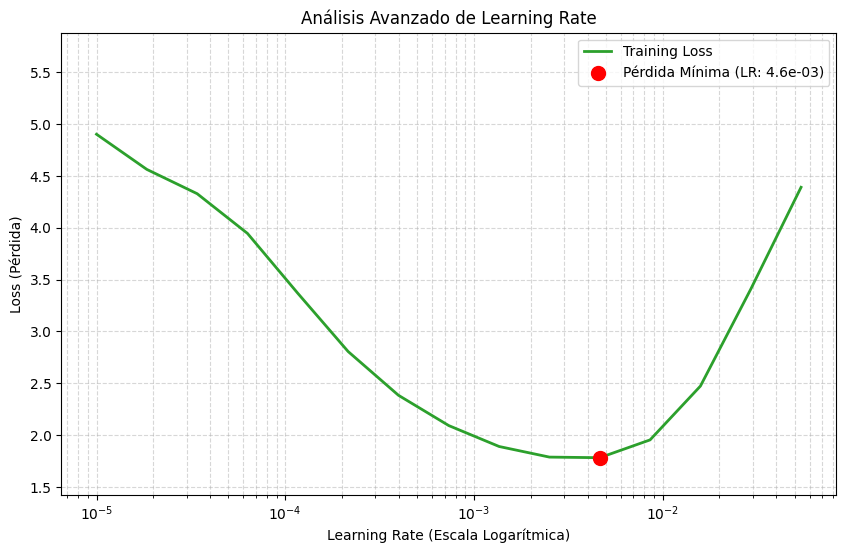

In [ ]:
# Extraer los datos
lrs = history_lr.history['learning_rate']
losses = history_lr.history['loss']

# Encontrar el índice donde la pérdida fue la más baja
min_loss_idx = np.argmin(losses)
min_lr = lrs[min_loss_idx]
min_loss = losses[min_loss_idx]

plt.figure(figsize=(10, 6))
plt.plot(lrs, losses, label='Training Loss', color='#2ca02c', linewidth=2)

# Resaltar el punto de pérdida mínima con un punto rojo
plt.scatter(min_lr, min_loss, color='red', s=100, zorder=5,
            label=f'Pérdida Mínima (LR: {min_lr:.1e})')

plt.xscale('log')

# --- EL TRUCO VISUAL ---
# Limitamos el eje Y para que el gráfico no se distorsione si el loss explota al final.
# El límite superior será un poco más alto que la pérdida inicial.
# El límite inferior será un poco más bajo que la pérdida mínima.
loss_inicial = losses[0]
plt.ylim([min_loss * 0.8, loss_inicial * 1.2])

plt.xlabel('Learning Rate (Escala Logarítmica)')
plt.ylabel('Loss (Pérdida)')
plt.title('Análisis Avanzado de Learning Rate')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.show()

Claramente se puede observar que un learning rate optimo para entrenar un modelo de Simple es el de 0.002

... ELIGIENDO EL MEJOR BATCHSIZE

In [ ]:
# Script de Benchmarking

# Define los tamaños de batch que quieres poner a prueba
batch_sizes_a_probar = [16, 32, 64, 128]
tiempos_entrenamiento = []

# 1. Crear un subconjunto FIJO de datos para que la comparación sea justa
# Tomamos 5000 imágenes de tu dataset base (asumiendo que 'ds_train_processed' aún NO tiene el .batch() aplicado)
NUM_IMAGENES_PRUEBA = 5000
ds_subset = ds_train_processed.take(NUM_IMAGENES_PRUEBA)

print(f"Iniciando prueba de rendimiento con {NUM_IMAGENES_PRUEBA} imágenes...\n")

for b_size in batch_sizes_a_probar:
    print(f"--- Evaluando Batch Size: {b_size} ---")

    # 2. Aplicar el batch_size y prefetch para optimizar la carga
    ds_test = ds_subset.batch(b_size).prefetch(tf.data.AUTOTUNE)

    # 3. Medir el tiempo exacto que le toma al modelo procesar los datos
    start_time = time.time()

    # Entrenamos por 1 sola época usando este subconjunto. verbose=0 oculta la barra de progreso
    model.fit(ds_test, epochs=1, verbose=0)

    end_time = time.time()

    tiempo_transcurrido = end_time - start_time
    tiempos_entrenamiento.append(tiempo_transcurrido)

    print(f"Tiempo: {tiempo_transcurrido:.2f} segundos.\n")

# Guardamos los resultados en un diccionario para la gráfica
resultados_benchmark = {
    'Batch_Size': [str(b) for b in batch_sizes_a_probar], # Convertir a string para mejor graficado categórico
    'Tiempo_Segundos': tiempos_entrenamiento
}
print("Prueba finalizada. Listo para graficar.")


Iniciando prueba de rendimiento con 5000 imágenes...

--- Evaluando Batch Size: 16 ---
Tiempo: 24.12 segundos.

--- Evaluando Batch Size: 32 ---
Tiempo: 6.56 segundos.

--- Evaluando Batch Size: 64 ---
Tiempo: 19.55 segundos.

--- Evaluando Batch Size: 128 ---
Tiempo: 21.43 segundos.

Prueba finalizada. Listo para graficar.


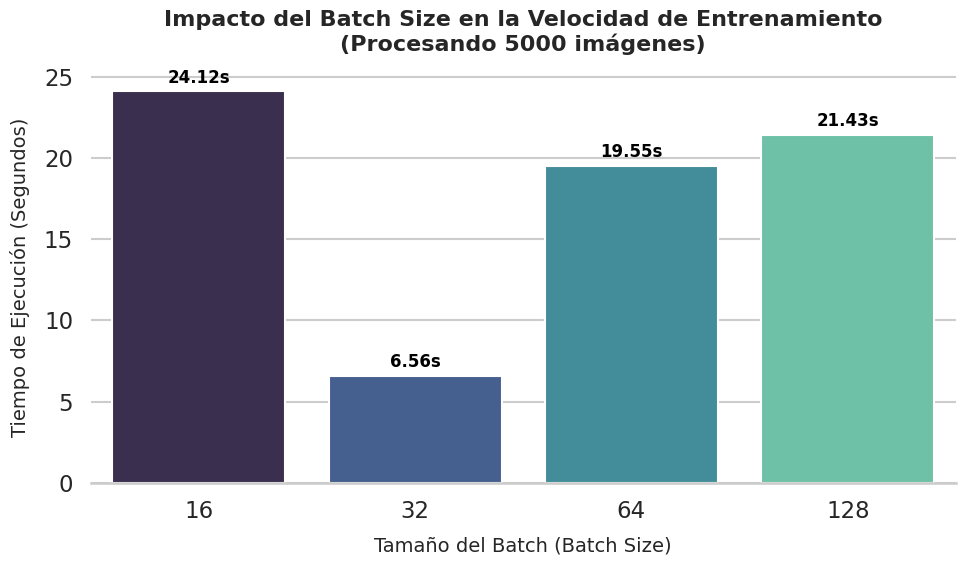

In [ ]:
# Convertir el diccionario de resultados en un DataFrame de Pandas
df_resultados = pd.DataFrame(resultados_benchmark)

# Configurar un estilo profesional y limpio
sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(10, 6))

# Crear el gráfico de barras
# Usamos una paleta secuencial donde colores más oscuros/claros ayudan a ver la progresión
ax = sns.barplot(
    x='Batch_Size',
    y='Tiempo_Segundos',
    data=df_resultados,
    palette="mako"
)

# Títulos y etiquetas profesionales
plt.title(f'Impacto del Batch Size en la Velocidad de Entrenamiento\n(Procesando {NUM_IMAGENES_PRUEBA} imágenes)',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Tamaño del Batch (Batch Size)', fontsize=14, labelpad=10)
plt.ylabel('Tiempo de Ejecución (Segundos)', fontsize=14, labelpad=10)

# Añadir el texto con el valor exacto encima de cada barra para mayor precisión
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}s",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                fontsize=12, color='black', fontweight='bold',
                xytext=(0, 10), textcoords='offset points')

# Eliminar bordes innecesarios para un look más moderno
sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.show()

El Batch Size optimo para entrenar el modelo, es el de 32

DIFERENTES ARQUITECTURAS

In [ ]:
def build_model_1(base_model, num_classes):
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = inputs

    # Extraer características
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    # Solo un Dropout fuerte directo a la salida
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name="Modelo_1_Minimalista")
    return model

def build_model_2(base_model, num_classes):
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = inputs

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    # Una sola capa densa intermedia
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.4)(x) # Previene que dependa demasiado de un solo nodo

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name="Modelo_2_Equilibrado")
    return model

def build_model_3(base_model, num_classes, learning_rate):
    # Crear el modelo funcional
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # Aplicar la capa de aumentación de datos (solo en entrenamiento)
    # Nota: Esta capa se incluye en el modelo para que las aumentaciones se realicen en la GPU
    # y sean consistentes durante el entrenamiento si se entrena el modelo de extremo a extremo.
    # Durante la inferencia, se comportará como una capa de paso (identity).
    x = inputs

    # Pasar las imágenes aumentadas al modelo base
    x = base_model(x, training=False) # Asegurarse de que el modelo base corra en modo inferencia

    # Añadir una capa de pooling global para reducir las dimensiones
    x = layers.GlobalAveragePooling2D()(x)

    # Ampliamos la capacidad inicial
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.BatchNormalization()(x) # Estabiliza y acelera el aprendizaje
    x = layers.Dropout(0.4)(x)

    # Segunda capa oculta (el embudo)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x) # Capa de salida con activación softmax para multiclase

    model = keras.Model(inputs, outputs)

    return model


In [ ]:
# Configuración (Ajusta estos valores si tus variables se llaman distinto)
NUM_CLASES = 101 # O 100 según tu dataset
LR = 2e-3 # Usa el Learning rate que encontraste en tu prueba anterior
EPOCAS_PRUEBA = 5

# Diccionario para guardar el historial de cada modelo
historiales = {}

# Lista de funciones para construir los modelos
# (Asegúrate de haber definido build_model_3 como en tu mensaje original)
constructores_modelos = [
    ("Modelo 1 (Minimalista)", build_model_1),
    ("Modelo 2 (Equilibrado)", build_model_2),
    ("Modelo 3 (Pesado)", build_model_3)
]

print("=" * 60)
print("INICIANDO TORNEO DE ARQUITECTURAS")
print("=" * 60)

for nombre_modelo, constructor in constructores_modelos:
    print(f"\n---> Entrenando {nombre_modelo} <---")

    # IMPORTANTE: Re-instanciar el modelo base en CADA iteración para que
    # no compartan pesos contaminados de la prueba anterior.
    # Reemplaza ResNet50 por el modelo base que estés usando.
    base_model_fresco = tf.keras.applications.ResNet50(
        weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model_fresco.trainable = False

    # Construir el modelo
    if nombre_modelo == "Modelo 3 (Pesado)":
        # Tu función requiere el LR como argumento (aunque en Keras se pasa al compilar)
        modelo_actual = constructor(base_model_fresco, NUM_CLASES, LR)
    else:
        modelo_actual = constructor(base_model_fresco, NUM_CLASES)

    # Compilar usando Sparse (como acordamos antes) y Accuracy
    modelo_actual.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=['accuracy']
    )

    # Entrenar por 5 épocas
    historia = modelo_actual.fit(
        ds_train_optimized,
        epochs=EPOCAS_PRUEBA,
        validation_data=ds_validation_optimized,
        verbose=1 # Mostrar progreso
    )

    # Guardar los resultados
    historiales[nombre_modelo] = historia.history

print("\nTorneo finalizado. ¡Listo para graficar!")

INICIANDO TORNEO DE ARQUITECTURAS

---> Entrenando Modelo 1 (Minimalista) <---
Epoch 1/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 158s 61ms/step - accuracy: 0.4617 - loss: 2.5904 - val_accuracy: 0.5709 - val_loss: 1.9578
Epoch 2/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 130s 54ms/step - accuracy: 0.5514 - loss: 2.2200 - val_accuracy: 0.6089 - val_loss: 1.8532
Epoch 3/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 130s 54ms/step - accuracy: 0.5704 - loss: 2.1612 - val_accuracy: 0.6112 - val_loss: 1.8849
Epoch 4/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 129s 54ms/step - accuracy: 0.5859 - loss: 2.1201 - val_accuracy: 0.6126 - val_loss: 2.0256
Epoch 5/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 130s 54ms/step - accuracy: 0.5957 - loss: 2.1075 - val_accuracy: 0.6163 - val_loss: 2.0471

---> Entrenando Modelo 2 (Equilibrado) <---
Epoch 1/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 165s 63ms/step - accuracy: 0.2939 - loss: 2.9033 - val_accuracy: 0.4933 - val_loss: 1.9711
Epoch 2/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 132s 55ms/step - accuracy: 0.3685 - loss: 2

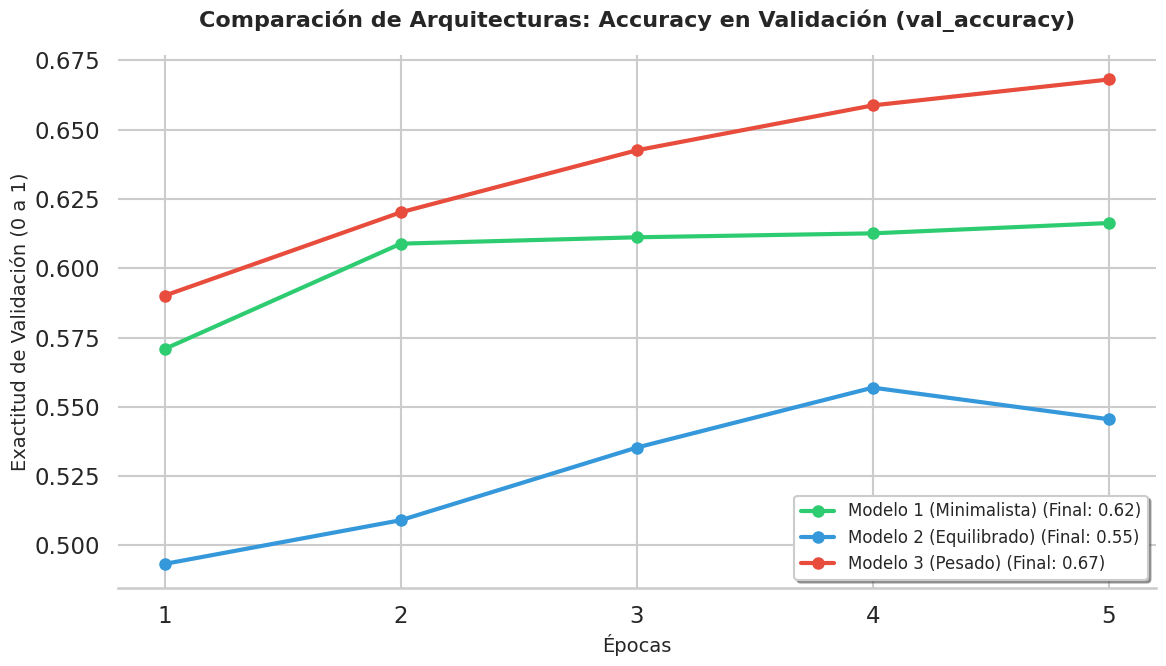

In [ ]:
sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(12, 7))

# Colores para distinguir los modelos
colores = ['#2ecc71', '#3498db', '#e74c3c']

for (nombre, datos_historia), color in zip(historiales.items(), colores):
    # Graficamos el val_accuracy de cada modelo
    plt.plot(
        range(1, EPOCAS_PRUEBA + 1),
        datos_historia['val_accuracy'],
        label=f"{nombre} (Final: {datos_historia['val_accuracy'][-1]:.2f})",
        linewidth=3,
        marker='o',
        markersize=8,
        color=color
    )

plt.title("Comparación de Arquitecturas: Accuracy en Validación (val_accuracy)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Épocas", fontsize=14)
plt.ylabel("Exactitud de Validación (0 a 1)", fontsize=14)

# Forzar que el eje X muestre números enteros (1, 2, 3...)
plt.xticks(range(1, EPOCAS_PRUEBA + 1))

plt.legend(loc="lower right", fontsize=12, frameon=True, shadow=True)
sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.show()

Recapitulando. Los hiperparámetros escogidos por el momento son:

Learning rate --> 2e-3

Batch Size --> 32

Arquitectura de Modelo --> 3 (pesado)

In [ ]:
def build_model_3_experiment(base_model, num_classes, usar_aumentacion=False):
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # Aplicar aumentación solo si se solicita
    if usar_aumentacion:
        x = data_augmentation(inputs)
    else:
        x = inputs

    # Pasar al modelo base en modo inferencia
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    # El "Cerebro" pesado de tu Modelo 3
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs)

# 3. Configuración del Experimento
NUM_CLASES = 101
LR = 2e-3
EPOCAS_EXPERIMENTO = 10 # 10 épocas son suficientes para ver la tendencia de separación

resultados_experimento = {}
opciones_experimento = [
    ("Modelo 3 (SIN Aumentación)", False),
    ("Modelo 3 (CON Aumentación Suave)", True)
]

print("=" * 60)
print("INICIANDO EXPERIMENTO DE DATA AUGMENTATION")
print("=" * 60)

for nombre, usar_aug in opciones_experimento:
    print(f"\n---> Entrenando: {nombre} <---")

    # MUY IMPORTANTE: Cargar un base_model limpio para cada iteración
    base_model_limpio = tf.keras.applications.ResNet50(
        weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model_limpio.trainable = False

    # Construir y compilar
    modelo = build_model_3_experiment(base_model_limpio, NUM_CLASES, usar_aumentacion=usar_aug)
    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=['accuracy']
    )

    # Entrenar (usamos ds_train_optimized que NO tiene aumentación previa aplicada con .map)
    historia = modelo.fit(
        ds_train_optimized,
        epochs=EPOCAS_EXPERIMENTO,
        validation_data=ds_validation_optimized,
        verbose=1
    )

    resultados_experimento[nombre] = historia.history

print("\nExperimento finalizado. Listo para visualizar.")

INICIANDO EXPERIMENTO DE DATA AUGMENTATION

---> Entrenando: Modelo 3 (SIN Aumentación) <---
Epoch 1/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 158s 61ms/step - accuracy: 0.4341 - loss: 2.2916 - val_accuracy: 0.6000 - val_loss: 1.4763
Epoch 2/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 132s 55ms/step - accuracy: 0.5316 - loss: 1.8105 - val_accuracy: 0.6264 - val_loss: 1.3689
Epoch 3/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 132s 55ms/step - accuracy: 0.5664 - loss: 1.6622 - val_accuracy: 0.6404 - val_loss: 1.3099
Epoch 4/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 132s 55ms/step - accuracy: 0.5889 - loss: 1.5624 - val_accuracy: 0.6543 - val_loss: 1.2541
Epoch 5/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 132s 55ms/step - accuracy: 0.6054 - loss: 1.4900 - val_accuracy: 0.6697 - val_loss: 1.2035
Epoch 6/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 132s 55ms/step - accuracy: 0.6201 - loss: 1.4234 - val_accuracy: 0.6756 - val_loss: 1.1832
Epoch 7/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 132s 55ms/step - accuracy: 0.6311 - loss: 1.3760 - val_accuracy: 0.

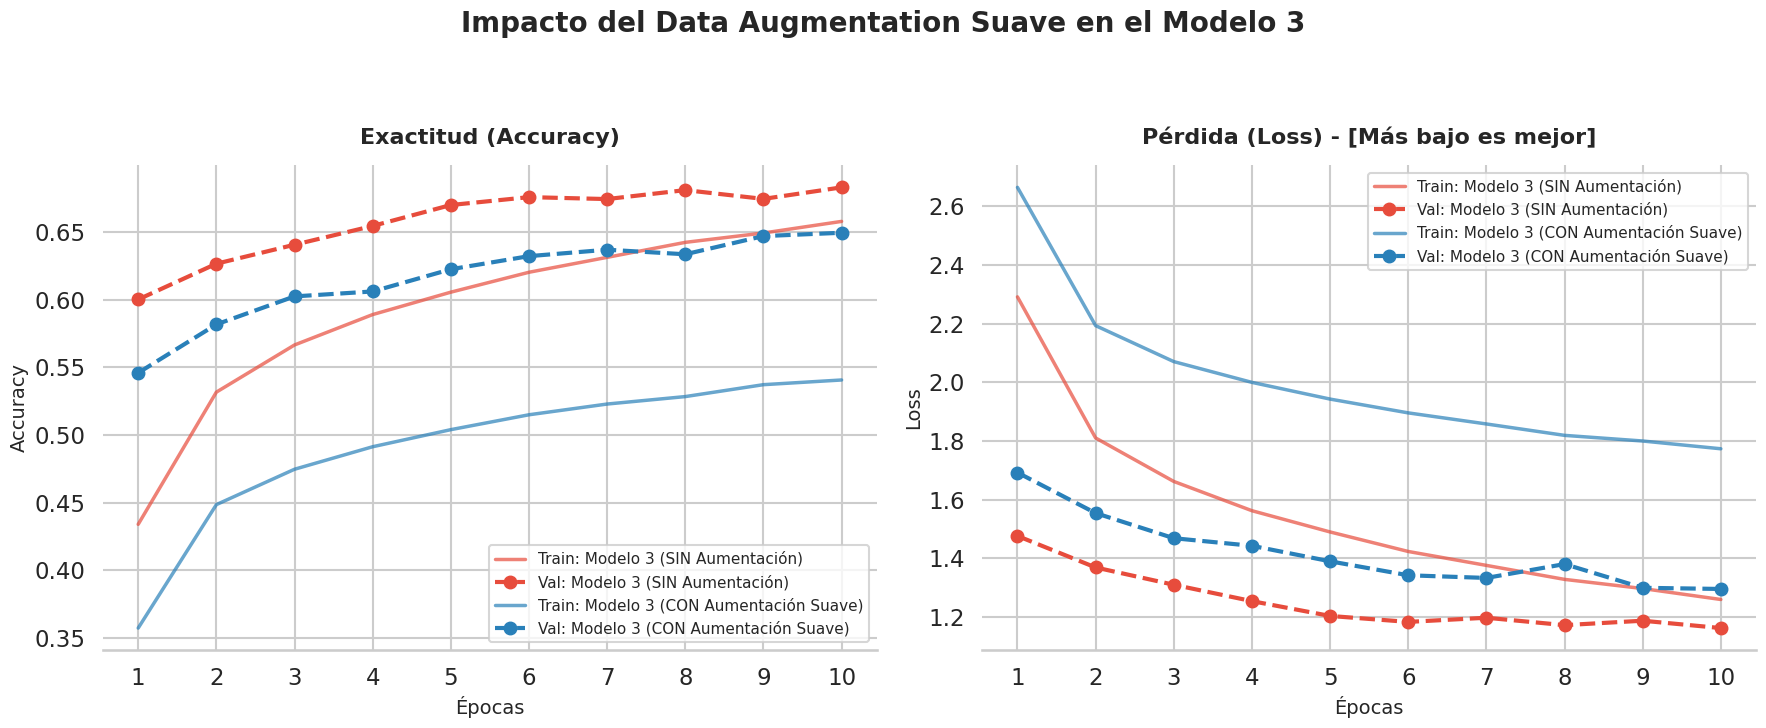

In [ ]:
sns.set_theme(style="whitegrid", context="talk")

# Crear una figura con 2 subgráficos (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Impacto del Data Augmentation Suave en el Modelo 3', fontsize=20, fontweight='bold', y=1.05)

epocas = range(1, EPOCAS_EXPERIMENTO + 1)
colores = ['#e74c3c', '#2980b9'] # Rojo para SIN aumentación, Azul para CON aumentación

for (nombre, historia), color in zip(resultados_experimento.items(), colores):

    # PANEL 1: Accuracy (Exactitud)
    # Línea continua para Training, línea punteada para Validation
    ax1.plot(epocas, historia['accuracy'], label=f'Train: {nombre}', color=color, linestyle='-', linewidth=2.5, alpha=0.7)
    ax1.plot(epocas, historia['val_accuracy'], label=f'Val: {nombre}', color=color, linestyle='--', linewidth=3, marker='o')

    # PANEL 2: Loss (Pérdida)
    ax2.plot(epocas, historia['loss'], label=f'Train: {nombre}', color=color, linestyle='-', linewidth=2.5, alpha=0.7)
    ax2.plot(epocas, historia['val_loss'], label=f'Val: {nombre}', color=color, linestyle='--', linewidth=3, marker='o')

# Configurar Panel 1 (Accuracy)
ax1.set_title('Exactitud (Accuracy)', fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel('Épocas', fontsize=14)
ax1.set_ylabel('Accuracy', fontsize=14)
ax1.set_xticks(epocas)
ax1.legend(fontsize=11, loc='lower right')

# Configurar Panel 2 (Loss)
ax2.set_title('Pérdida (Loss) - [Más bajo es mejor]', fontsize=16, fontweight='bold', pad=15)
ax2.set_xlabel('Épocas', fontsize=14)
ax2.set_ylabel('Loss', fontsize=14)
ax2.set_xticks(epocas)
ax2.legend(fontsize=11, loc='upper right')

# Limpieza visual
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

Recapitulando. Los hiperparámetros escogidos por el momento son:

Learning rate --> 2e-3

Batch Size --> 32

Arquitectura de Modelo --> 3 (pesado)

DataAugmentation --> False

Ahora solo queda por conocer cuantas capas del modelo Resnet50 descongelar, para lograr una mejor predicción en el modelo. Pero primero, habria que entrenar nuevamente el modelo pero con más epocas y un sistema de detención si determinadas alertas coinciden activarse.

Se decantará usar AdamW porque suele tener mejor resultado con modelos mas complejos, ya que tienden a sobreajustar a mayores epocas entrenadas.

## 6. DESARROLLO DEL MODELO DE CABEZA DE RESNET50

In [ ]:
# Hiperparametros

# Configuración
IMG_SIZE = 224
BATCH_SIZE = 32

LR_FE = 0.002
LR_FT = 0.0001
#NUM_CLASSES = 101

In [ ]:
def build_model_3(base_model, num_classes):
    # Crear el modelo funcional
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = inputs

    # Pasar las imágenes aumentadas al modelo base
    x = base_model(x, training=False) # Asegurarse de que el modelo base corra en modo inferencia

    # Añadir una capa de pooling global para reducir las dimensiones
    x = layers.GlobalAveragePooling2D()(x)

    # Ampliamos la capacidad inicial
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.BatchNormalization()(x) # Estabiliza y acelera el aprendizaje
    x = layers.Dropout(0.4)(x)

    # Segunda capa oculta (el embudo)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x) # Capa de salida con activación softmax para multiclase

    model = keras.Model(inputs, outputs)

    return model


In [ ]:
# MODELO CABECERA

# Construir el modelo usando la función definida
# En la primera fase, entrenaremos solo el clasificador, por lo que usaremos LR_FE
model_cab = build_model_3(base_resnet, NUM_CLASSES)

print("Modelo construido con éxito.")
model_cab.summary()

Modelo construido con éxito.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 101)            │        51,813 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,268,645 (100.21 MB)

 Trainable params: 2,677,861 (10.22 MB)

 Non-trainable params: 23,590,784 (89.99 MB)

In [ ]:
model_cab.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=LR_FE),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=['accuracy'])


In [ ]:
print("\n" + "=" * 60)
print("INICIANDO ENTRENAMIENTO DEL CLASIFICADOR")
print("=" * 60)
# CALLBACKS

# 1. EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# 2. ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=0.00001,
    verbose=1
)

print("Callbacks 'EarlyStopping' y 'ReduceLROnPlateau' configurados con éxito.")

# Puedes agruparlos en una lista para pasarlos al método model.fit()
callbacks = [early_stopping, reduce_lr]
#print(f"Lista de callbacks para el entrenamiento: {callbacks}")


INICIANDO ENTRENAMIENTO DEL CLASIFICADOR
Callbacks 'EarlyStopping' y 'ReduceLROnPlateau' configurados con éxito.


In [ ]:

# Entrenar por 30 épocas
historia_model_cab = model_cab.fit(
        ds_train_optimized,
        epochs=30,
        validation_data=ds_validation_optimized,
        callbacks=callbacks,
        verbose=1 # Mostrar progreso
    )

Epoch 1/30
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 110s 38ms/step - accuracy: 0.4353 - loss: 2.2912 - val_accuracy: 0.5924 - val_loss: 1.4999 - learning_rate: 0.0020
Epoch 2/30
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 58s 25ms/step - accuracy: 0.5325 - loss: 1.8118 - val_accuracy: 0.6200 - val_loss: 1.3962 - learning_rate: 0.0020
Epoch 3/30
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 59s 25ms/step - accuracy: 0.5600 - loss: 1.6812 - val_accuracy: 0.6415 - val_loss: 1.3096 - learning_rate: 0.0020
Epoch 4/30
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 58s 25ms/step - accuracy: 0.5851 - loss: 1.5789 - val_accuracy: 0.6556 - val_loss: 1.2646 - learning_rate: 0.0020
Epoch 5/30
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 58s 25ms/step - accuracy: 0.6012 - loss: 1.5098 - val_accuracy: 0.6638 - val_loss: 1.2339 - learning_rate: 0.0020
Epoch 6/30
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 58s 25ms/step - accuracy: 0.6162 - loss: 1.4457 - val_accuracy: 0.6634 - val_loss: 1.2249 - learning_rate: 0.0020
Epoch 7/30
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 59s 25ms/step - accur

In [ ]:
# Grabar Modelo

model_cab.save('modelo_food101_clasificador.keras')
print("Modelo guardado exitosamente en formato .keras")


Modelo guardado exitosamente en formato .keras


## 7. DESCONGELAMIENTO DEL RESNET50


La idea principal es primero observar que combinacion de capas del modelo RESNET50 habría que descongelar para lograr la mejor convergencia del accuracy, y después encontrar el mejor learning rate microscópico para que el modelo pueda aprovechar mejor las bondades del RESNET50, y luego entrenar la arquitectura escogida por 30 epocas, y ese será el modelo final.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Cargamos el modelo
ruta_modelo = '/content/drive/MyDrive/EAE - Python Basics/Redes Neuronales/Trabajo Final de Curso/modelo_food101_clasificador.keras'
model_cab = tf.keras.models.load_model(ruta_modelo)

Experimentamos con cuantas capas descongelamos el RESNET50.

In [ ]:
import gc # IMPORTANTE: El Garbage Collector de Python

# Definimos los experimentos
experimentos = [
    {'nombre': 'Conservador', 'bloques': ['conv5']},
    {'nombre': 'Agresivo', 'bloques': ['conv4', 'conv5']},
    {'nombre': 'Muy_Agresivo', 'bloques': ['conv3', 'conv4', 'conv5']}
]

resultados_torneo = {}
LR_FINE_TUNING = 1e-5

for exp in experimentos:
    print(f"\n============================================================")
    print(f"INICIANDO PRUEBA RÁPIDA: {exp['nombre']} (Descongelando: {exp['bloques']})")
    print(f"============================================================")

    # 1. DEFENSA 1: Limpieza profunda antes de empezar
    keras.backend.clear_session()
    gc.collect()

    # Cargar el modelo
    modelo_top = load_model(ruta_modelo)

    # Localizar la base ResNet50
    base_resnet_test = None
    for layer in modelo_top.layers:
        if isinstance(layer, keras.Model) and len(layer.layers) > 50:
            base_resnet_test = layer
            break

    if base_resnet_test is None:
        raise ValueError("No se pudo encontrar ResNet50 dentro del modelo.")

    # Configurar qué descongelar
    base_resnet_test.trainable = True
    for layer in base_resnet_test.layers:
        layer.trainable = True

        if not any(bloque in layer.name for bloque in exp['bloques']):
            layer.trainable = False

        if isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = False

    # Recompilar
    modelo_top.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=LR_FINE_TUNING),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )

    # Entrenar
    history = modelo_top.fit(
        ds_train_optimized,
        epochs=4,
        validation_data=ds_validation_optimized,
        verbose=1
    )

    # Guardar resultados
    resultados_torneo[exp['nombre']] = history.history['val_loss'][-1]

    # ============================================================
    # 2. DEFENSA 2: Destrucción explícita del modelo en memoria
    # ============================================================
    del modelo_top
    del base_resnet_test
    del history

    # 3. DEFENSA 3: Forzar la limpieza final de la tarjeta gráfica y la RAM
    keras.backend.clear_session()
    gc.collect()
    print("-> Memoria liberada exitosamente para la siguiente prueba.")

# Resultados
print("\n" + "="*40)
print("🏆 VEREDICTO DEL MINI-TORNEO 🏆")
print("="*40)
resultados_ordenados = sorted(resultados_torneo.items(), key=lambda x: x[1])

for i, (nombre, val_loss) in enumerate(resultados_ordenados):
    if i == 0:
        print(f"🥇 GANADOR -> Configuración '{nombre}': val_loss = {val_loss:.4f}")
    else:
        print(f"   Posición {i+1} -> Configuración '{nombre}': val_loss = {val_loss:.4f}")


INICIANDO PRUEBA RÁPIDA: Conservador (Descongelando: ['conv5'])
Epoch 1/4
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 214s 79ms/step - accuracy: 0.7263 - loss: 0.9835 - val_accuracy: 0.7187 - val_loss: 1.0324
Epoch 2/4
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 166s 70ms/step - accuracy: 0.7693 - loss: 0.8131 - val_accuracy: 0.7248 - val_loss: 1.0178
Epoch 3/4
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 167s 70ms/step - accuracy: 0.8082 - loss: 0.6788 - val_accuracy: 0.7272 - val_loss: 1.0042
Epoch 4/4
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 166s 70ms/step - accuracy: 0.8386 - loss: 0.5662 - val_accuracy: 0.7281 - val_loss: 1.0059
-> Memoria liberada exitosamente para la siguiente prueba.

INICIANDO PRUEBA RÁPIDA: Agresivo (Descongelando: ['conv4', 'conv5'])
Epoch 1/4
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 260s 98ms/step - accuracy: 0.7216 - loss: 0.9998 - val_accuracy: 0.7243 - val_loss: 1.0097
Epoch 2/4
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 215s 91ms/step - accuracy: 0.7768 - loss: 0.7854 - val_accuracy: 0.7389 - val_loss: 0.9566
Epoch 3/4
236

Ahora que sabemos cuantas capas de Descongelamiento nos da el mejor resultado. Lo mejor es determinar que learning rate favorece el tratamiento de estas capas para personalizarlas al modelo de cabecera.

In [ ]:

# 1. Definimos los Learning Rates candidatos a competir
# Probamos desde un valor ultra-seguro hasta uno rozando el límite del olvido
tasas_a_probar = {
    'Ultra_Seguro': 1e-6,
    'Conservador': 5e-6,
    'Estándar': 1e-5,
    'Agresivo': 5e-5
}

# 2. FIJAMOS la configuración de bloques que ganó en tu torneo anterior
# Reemplaza esto con el ganador real de tu prueba
BLOQUES_GANADORES = ['conv3', 'conv4', 'conv5']

resultados_lr = {}

for nombre_lr, lr_value in tasas_a_probar.items():
    print(f"\n============================================================")
    print(f"INICIANDO PRUEBA LR: {nombre_lr} (Learning Rate: {lr_value})")
    print(f"============================================================")

    # Limpiamos memoria
    keras.backend.clear_session()

    # Cargar el modelo base recién salido de la Fase 1 (Solo cabecera entrenada)
    modelo_top = load_model(ruta_modelo) # Asegúrate de que 'ruta' apunte al modelo correcto

    # Localizar ResNet50
    base_resnet_test = None
    for layer in modelo_top.layers:
        if isinstance(layer, keras.Model) and len(layer.layers) > 50:
            base_resnet_test = layer
            break

    if base_resnet_test is None:
        raise ValueError("No se pudo encontrar ResNet50.")

    # Descongelar según tu configuración ganadora
    base_resnet_test.trainable = True
    for layer in base_resnet_test.layers:
        layer.trainable = True

        # Si la capa no pertenece a los bloques ganadores, se congela
        if not any(bloque in layer.name for bloque in BLOQUES_GANADORES):
            layer.trainable = False

        # Siempre congelar BatchNormalization
        if isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = False

    # RECOMPILAR con el Learning Rate actual del bucle
    modelo_top.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=lr_value),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy'] # Mantenlo simple
    )

    # Entrenar por un periodo corto (3 a 5 épocas es suficiente para ver la tendencia)
    history = modelo_top.fit(
        ds_train_optimized,
        epochs=4,
        validation_data=ds_validation_optimized,
        verbose=1
    )

    # Evaluar el resultado final
    val_loss_final = history.history['val_loss'][-1]
    val_acc_final = history.history['val_accuracy'][-1]

    resultados_lr[nombre_lr] = {
        'lr': lr_value,
        'val_loss': val_loss_final,
        'val_accuracy': val_acc_final
    }

# ==========================================
# RESULTADOS DEL TORNEO DE LEARNING RATES
# ==========================================
print("\n" + "="*50)
print("🏆 VEREDICTO DE LA TASA DE APRENDIZAJE 🏆")
print("="*50)

# Ordenamos los resultados por menor pérdida (loss)
resultados_ordenados_lr = sorted(resultados_lr.items(), key=lambda x: x[1]['val_loss'])

for i, (nombre, datos) in enumerate(resultados_ordenados_lr):
    if i == 0:
        print(f"🥇 GANADOR -> {nombre} (LR: {datos['lr']}) | Loss: {datos['val_loss']:.4f} | Acc: {datos['val_accuracy']:.4f}")
    else:
        print(f"   Posición {i+1} -> {nombre} (LR: {datos['lr']}) | Loss: {datos['val_loss']:.4f} | Acc: {datos['val_accuracy']:.4f}")

print("\nSiguiente paso: Inicia tu entrenamiento final de Fine-Tuning (Fase 2) de 15-20 épocas utilizando este Learning Rate ganador y la configuración de bloques que elegiste.")


INICIANDO PRUEBA LR: Ultra_Seguro (Learning Rate: 1e-06)
Epoch 1/4
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 312s 118ms/step - accuracy: 0.7353 - loss: 0.9442 - val_accuracy: 0.7177 - val_loss: 1.0332
Epoch 2/4
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 260s 110ms/step - accuracy: 0.7498 - loss: 0.8870 - val_accuracy: 0.7223 - val_loss: 1.0178
Epoch 3/4
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 261s 110ms/step - accuracy: 0.7613 - loss: 0.8445 - val_accuracy: 0.7263 - val_loss: 1.0052
Epoch 4/4
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 260s 109ms/step - accuracy: 0.7716 - loss: 0.8080 - val_accuracy: 0.7282 - val_loss: 0.9967

INICIANDO PRUEBA LR: Conservador (Learning Rate: 5e-06)
Epoch 1/4
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 312s 119ms/step - accuracy: 0.7308 - loss: 0.9675 - val_accuracy: 0.7290 - val_loss: 0.9922
Epoch 2/4
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 260s 110ms/step - accuracy: 0.7702 - loss: 0.8112 - val_accuracy: 0.7352 - val_loss: 0.9644
Epoch 3/4
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 261s 110ms/step - accuracy: 0.8030 - loss: 0.6

El learning rate que ayudó al modelo a conseguir un mayor val_accuracy es el 1e-05, el lr estándar. No obstante, causa overfitting y posiblemente, cuando se entrene por mayor epocas, llegue a estancarse. En cambio, el learning rate ultra_seguro tuvo un accuracy algo menor... pero la diferencia entre el training_accuracy y el val_accuracy es hasta menos de la mitad del learning rate estandar. Debido a ello, es mejor definir el learning rate como 2e-06, para poder observar un mejor desarrollo por más épocas.

COMO APRENDIZAJE... PROBAR CON UN DROPOUT MAS ALTO PARA ENTRENAR LA CABECERA DEL MODELO, Y ASI EVITAR EL OVERFITTING CUANDO SE ENTRENE POR MAS EPOCAS.

## 8. ENTRENAMIENTO Y GUARDADO DE MODELO FINAL

In [ ]:
import gc

# Limpieza inicial
keras.backend.clear_session()
gc.collect()

# ==========================================
# 1. CONFIGURACIÓN MAESTRA
# ==========================================
# Reemplaza con la ruta de tu modelo entrenado de la FASE 1
RUTA_MODELO_FASE1 = '/content/drive/MyDrive/EAE - Python Basics/Redes Neuronales/Trabajo Final de Curso/modelo_food101_clasificador.keras'
LR_FINAL = 2.5e-06 # Tu elección experta
EPOCAS_FINALES = 30
BLOQUES_GANADORES = ['conv3', 'conv4', 'conv5']

print("Cargando modelo de la Fase 1...")
modelo_final = load_model(RUTA_MODELO_FASE1)

Cargando modelo de la Fase 1...


In [ ]:
# ==========================================
# 2. DESCONGELAMIENTO QUIRÚRGICO
# ==========================================
base_resnet = None
for layer in modelo_final.layers:
    if isinstance(layer, keras.Model) and len(layer.layers) > 50:
        base_resnet = layer
        break

base_resnet.trainable = True

for layer in base_resnet.layers:
    layer.trainable = True
    # Congelar si no pertenece a tus bloques ganadores
    if not any(bloque in layer.name for bloque in BLOQUES_GANADORES):
        layer.trainable = False
    # Siempre congelar BatchNormalization
    if isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = False

print(f"Capas de ResNet habilitadas para Fine-Tuning: {len([l for l in base_resnet.layers if l.trainable])}")

Capas de ResNet habilitadas para Fine-Tuning: 94


In [ ]:
# ==========================================
# 3. RECOMPILACIÓN Y CALLBACKS
# ==========================================
modelo_final.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=LR_FINAL, weight_decay=1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

callbacks_finales = [
    # Si la validación no mejora en 4 épocas, nos detenemos y guardamos lo mejor
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1),
    # Si el val_loss se estanca 2 épocas, reducimos tu LR a la mitad para ajustes microscópicos
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1)
]

In [ ]:
# ==========================================
# 4. EL ENTRENAMIENTO
# ==========================================
print("\n" + "=" * 60)
print("🚀 INICIANDO FINE-TUNING DEFINITIVO")
print("=" * 60)

history_final = modelo_final.fit(
    ds_train_optimized,
    epochs=EPOCAS_FINALES,
    validation_data=ds_validation_optimized,
    callbacks=callbacks_finales,
    verbose=1
)


🚀 INICIANDO FINE-TUNING DEFINITIVO
Epoch 1/30
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 174s 57ms/step - accuracy: 0.7358 - loss: 0.9478 - val_accuracy: 0.7237 - val_loss: 1.0130 - learning_rate: 2.5000e-06
Epoch 2/30
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 107s 45ms/step - accuracy: 0.7630 - loss: 0.8476 - val_accuracy: 0.7325 - val_loss: 0.9878 - learning_rate: 2.5000e-06
Epoch 3/30
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 108s 45ms/step - accuracy: 0.7790 - loss: 0.7744 - val_accuracy: 0.7337 - val_loss: 0.9765 - learning_rate: 2.5000e-06
Epoch 4/30
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 107s 45ms/step - accuracy: 0.8021 - loss: 0.7012 - val_accuracy: 0.7341 - val_loss: 0.9760 - learning_rate: 2.5000e-06
Epoch 5/30
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 107s 45ms/step - accuracy: 0.8185 - loss: 0.6399 - val_accuracy: 0.7370 - val_loss: 0.9692 - learning_rate: 2.5000e-06
Epoch 6/30
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 107s 45ms/step - accuracy: 0.8337 - loss: 0.5866 - val_accuracy: 0.7389 - val_loss: 0.9612 - learning_rate: 2.5000e-0

In [ ]:
# ==========================================
# 5. EXPORTACIÓN PARA PRODUCCIÓN
# ==========================================
print("\n" + "=" * 60)
print("📦 EXPORTANDO ARCHIVOS PARA DESPLIEGUE")
print("=" * 60)

# Guardar el modelo en formato .keras (Te recomiendo guardarlo en tu Drive)
ruta_guardado = '/content/drive/MyDrive/EAE - Python Basics/Redes Neuronales/Trabajo Final de Curso/Clasificador_Food101_PRO.keras'
modelo_final.save(ruta_guardado)
print(f"✅ Modelo guardado en: {ruta_guardado}")

# Extraer y guardar el JSON con los nombres (Asegúrate de que ds_info siga cargado en memoria)
try:
    nombres_clases = ds_info.features['label'].names
    ruta_json = '/content/drive/MyDrive/EAE - Python Basics/Redes Neuronales/Trabajo Final de Curso/clases_food101.json'
    with open(ruta_json, 'w') as f:
        json.dump(nombres_clases, f)
    print(f"✅ Diccionario JSON guardado en: {ruta_json}")
except Exception as e:
    print(f"⚠️ No se pudo guardar el JSON. Asegúrate de tener 'ds_info' disponible. Error: {e}")

print("\n🎉 ¡PROYECTO ENTRENADO Y LISTO PARA HUGGING FACE / GRADIO! 🎉")


📦 EXPORTANDO ARCHIVOS PARA DESPLIEGUE
✅ Modelo guardado en: /content/drive/MyDrive/EAE - Python Basics/Redes Neuronales/Trabajo Final de Curso/Clasificador_Food101_PRO.keras
✅ Diccionario JSON guardado en: /content/drive/MyDrive/EAE - Python Basics/Redes Neuronales/Trabajo Final de Curso/clases_food101.json

🎉 ¡PROYECTO ENTRENADO Y LISTO PARA HUGGING FACE / GRADIO! 🎉
